In [1]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load cleaned data
movies = pd.read_csv("../outputs/movies_cleaned.csv")
ratings = pd.read_csv("../outputs/ratings_cleaned.csv")

In [3]:
#Merge movies and ratings
movie_ratings = ratings.merge(movies, on="movieId")

In [4]:
#Find total movies
total_movies = movies["movieId"].nunique()

In [5]:
#Find total users
total_users = ratings["userId"].nunique()

In [6]:
#Find total ratings
total_ratings = ratings.shape[0]

In [7]:
#Find average rating
average_rating = ratings["rating"].mean()

In [8]:
#Find top rated movies
top_rated = movie_ratings.groupby("clean_title")["rating"].mean().sort_values(ascending=False).head(10)

In [9]:
#Find most rated movies
most_rated = movie_ratings.groupby("clean_title")["rating"].count().sort_values(ascending=False).head(10)

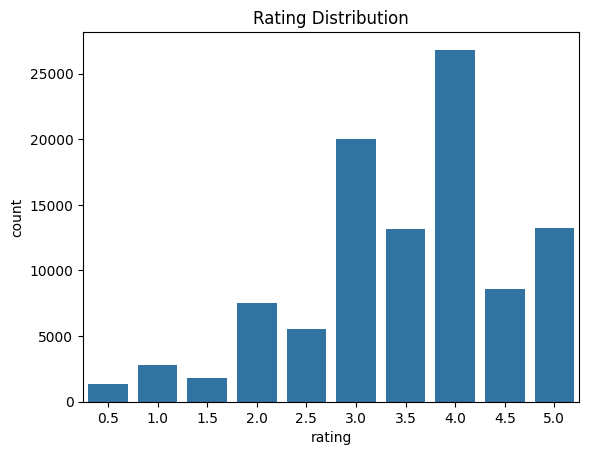

In [10]:
#Analyze rating distribution
sns.countplot(data=ratings, x="rating")
plt.title("Rating Distribution")
plt.show()

In [11]:
#Analyze genre popularity
genre_data = movies.assign(genres=movies["genres"].str.split("|")).explode("genres")
genre_count = genre_data["genres"].value_counts()

In [12]:
#Save analysis files for Power BI
genre_count.to_csv("../outputs/genre_popularity.csv")
top_rated.to_csv("../outputs/top_rated_movies.csv")
most_rated.to_csv("../outputs/most_rated_movies.csv")